# 03 · Advanced

Six sections, each one standing on its own. Every section builds its own programs and declares the numbers only it uses, so you can read them in any order and run any one of them once the three setup cells below have run.

Two are about writing less. A **fragment** factors a repeated sequence into a named, parameterized sub-program. A **conditional** lets a measurement decide what the program does next, inside the run rather than after it.

Two are about adding to the language. You will write your own **waveform** and your own **sweep source**, and then your own **vendor namespace** beside the two published extension packages that carry real instruments.

And two are about the machine. **`PlatformProtocol`** is the interface a back-end implements, six members wide. **`PlatformCapabilities`** is how a machine writes down what it can run, and `qp.validate`, `qp.explain`, and `qp.optimize` are what read it, so a program is checked and replanned before it is ever uploaded.

In [1]:
# Run me first. A no-op when everything is installed, an install when something is missing
# (a fresh Google Colab runtime, for example). Section 3.4 shows a file loading a vendor
# extension on demand, so this cell probes for the packages rather than importing them.
from importlib.util import find_spec

if any(find_spec(name) is None for name in ("qprogram", "qprogram_qblox", "qprogram_qdac")):
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "qprogram[viz]==0.2.0", "qprogram-qblox==0.2.0", "qprogram-qdac==0.2.0",
        ],
        check=True,
    )

from importlib.metadata import version

print("qprogram", version("qprogram"))
print("qprogram-qblox", version("qprogram-qblox"), "and qprogram-qdac", version("qprogram-qdac"))

qprogram 0.2.0
qprogram-qblox 0.2.0 and qprogram-qdac 0.2.0


In [2]:
import sys
import warnings
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import qprogram as qp
from qprogram import MeasurementField
from qprogram.buses import BusSchema
from qprogram.plotting import Quantity, Style
from qprogram.waveforms import IQDrag, IQPair, Square

## Shared names

Six names are used by more than one section, so they live here rather than in whichever section happens to reach one first. Two are bus names, the drive line and the readout line of a single qubit. `DRIVE_FREQ` is that qubit's transition frequency, the tone that rotates it between the two levels used as 0 and 1. The three `BIAS_` numbers describe a scan of the flux bias that tunes the same transition, in volts on the line that carries it.

Both bus names are plain strings rather than schema references, because the first four sections are about the seams of the language and not about the chip. The checks of section 1.4 are therefore not in play until section 3.5 attaches a schema.

Everything else a section needs is declared inside the section.

In [3]:
DRIVE = "q0/drive"  # the qubit 0 drive line
READOUT = "q0/readout"  # the qubit 0 readout line

DRIVE_FREQ = 4.85e9  # Hz, the qubit 0 to 1 transition
BIAS_START, BIAS_STOP, BIAS_POINTS = -0.05, 0.15, 41  # V, V, and how many points across that span

## 3.1 Fragments

Three experiments that play the same two pulses want one definition of those pulses rather than three copies that drift apart. A `Fragment` is that definition, a named and parameterized sub-program, and `program.call` appends one node for it.

`@qp.fragment` turns a plain function into one. The first argument is the fragment being built, and every argument after it becomes a parameter, in declaration order. The decorator reads a plain positional signature, so a default value, a `*args`, or a keyword-only argument is refused at the `def` rather than at the call.

In [4]:
PULSE_AMP = 0.5  # DAC units, a round number for the pulses this section plays


@qp.fragment
def x_pulse(f, drive, amp):
    """One rotation pulse. `f` is the fragment being built, not a program."""
    f.play(drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))


demo = qp.QProgram(label="one_call")
demo.call(x_pulse, DRIVE, PULSE_AMP)  # positional, in declaration order
demo.call(x_pulse, DRIVE, amp=PULSE_AMP / 2)  # or by keyword, Python's own binding rules

print(qp.dumps(demo))

#!QProgram 0.2

metadata:
  label: "one_call"

fragment x_pulse(drive, amp):
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)

body:
  x_pulse("q0/drive", 0.5)
  x_pulse("q0/drive", 0.25)



The definition came out as a `fragment` section above the body and each call site stayed one line, so a reader of the `.qp` file sees the structure you wrote rather than an inlining of it.

A parameter is an untyped placeholder, so one may stand for a number, a bus, or a waveform, and the binding at the call site decides which. It is also an ordinary expression operand, so `2 * amp` inside a definition is recorded rather than computed. The second call above shows the same thing from the other side: `amp / 2` was folded by Python before the call, because that arithmetic happened on a float at the call site.

The decorator is strict about the signature it will read.

In [5]:
def with_default(f, drive, amp=0.5):
    """A default value has no meaning at a call site the fragment does not control."""


def with_star_args(f, *args):
    """A parameter list has to be known when the definition is recorded."""


for candidate in (with_default, with_star_args):
    try:
        qp.fragment(candidate)
    except qp.ValidationError as exc:
        print(f"{candidate.__name__}: {exc}")

with_default: @fragment 'with_default': parameter 'amp' has a default value; defaults are not supported
with_star_args: @fragment 'with_star_args': parameter 'args' is variadic positional; only plain positional parameters are supported


### The body runs once

The decorated function is called once, when the decorator runs, and what it records is the tree. Ordinary Python inside the body therefore executes at definition time rather than per call, so a `for` loop writes its copies into the definition and the count is chosen by the code that defines the fragment rather than by the code that calls it.

In [6]:
N_PULSES = 3  # how many pulses the train holds, fixed when the fragment is defined
PULSE_NS = 40  # ns, the length of one pulse in the train


@qp.fragment
def pulse_train(f, drive, spacing):
    """A train of pulses, each one `spacing` nanoseconds after the last."""
    for _ in range(N_PULSES):
        f.wait(drive, spacing)
        f.play(drive, "pi")


train = qp.QProgram(label="two_calls")
train.call(pulse_train, DRIVE, 100)
train.call(pulse_train, DRIVE, 200)

print(qp.dumps(train).split("body:")[0].rstrip())
print("\nand the two call sites, unrolled nowhere:")
print("\n".join(line for line in qp.dumps(train).splitlines() if line.strip().startswith("pulse_train")))

#!QProgram 0.2

metadata:
  label: "two_calls"

fragment pulse_train(drive, spacing):
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"

and the two call sites, unrolled nowhere:
  pulse_train("q0/drive", 100)
  pulse_train("q0/drive", 200)


### `expand()`

`expand()` returns a new program with every call replaced by a plain block holding the substituted body, and validation and execution run it for you, so it is the thing to print when you want to see what a compiler will get.

Two kinds of name cannot survive inlining as they are, and expansion rewrites both. A fragment declares variables of its own with the same `variable()` call a program uses, and each becomes `{fragment}_{id}` on the host, with a numeric suffix when two calls collide. A measurement's auto-generated name normally embeds its bus, and inside a fragment the bus is still a parameter, so the name is a plain `m0` and repeated calls are suffixed.

One consequence follows from that. The handle lives in the definition, so `measurement_handles()` on the host program sees nothing until you expand. Keeping the pulses in fragments and leaving `measure` in the host program is the arrangement that avoids the whole question, and the last cell of this section does exactly that.

In [7]:
settle = qp.Fragment("settle")  # the other spelling, for when the parameters are computed
settle_bus = settle.parameter("bus")
delay = settle.variable("n", label="Settling time", units="ns")
with settle.sweep(delay, qp.Range(0, 200, 100)):
    settle.wait(settle_bus, delay)
settle.measure(settle_bus, "probe", "weights", fields=(MeasurementField.STATE,))

host = qp.QProgram(label="two_readouts")
host.call(settle, READOUT)
host.call(settle, "q1/readout")

print("handles before expand:", [h.name for h in host.measurement_handles()])
flat = host.expand()
print("handles after expand: ", [h.name for h in flat.measurement_handles()])
print("variables after expand:", [v.id for v in flat.variables])
print("fragments left to define:", list(flat.fragments), "against", list(host.fragments))

handles before expand: []
handles after expand:  ['m0', 'm0_2']
variables after expand: ['settle_n', 'settle_n_2']
fragments left to define: [] against ['settle']


### Binding waveforms

`with_waveforms` does not follow a `call`, so an alias inside a definition stays a string until the call has been inlined. Expand first, then bind.

In [8]:
library = {
    "pi": IQDrag(amplitude=PULSE_AMP, duration=PULSE_NS, sigma=10, beta=0.1),
    "probe": IQPair(Square(1.0, 2000), Square(0.0, 2000)),
    "weights": IQPair(Square(1.0, 2000), Square(1.0, 2000)),
}

def play_line(program):
    """The first play statement in a program's `.qp` text."""
    for line in qp.dumps(program).splitlines():
        if line.strip().startswith("play"):
            return line.strip()
    return "no play statement"


print("bound as written:     ", play_line(train.with_waveforms(library)))
print("expanded, then bound: ", play_line(train.expand().with_waveforms(library)))

bound as written:      play drive "pi"
expanded, then bound:  play "q0/drive" IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)


### One fragment, one experiment

The experiment below sweeps the spacing of the train and reads the qubit out at every point. The pulses live in the fragment and the `measure` lives in the host program, so the handle stays an ordinary Python variable.

The model is an exponential decay in the total time the sequence occupies, the shape a coherence measurement has from the outside. The train holds `N_PULSES` repetitions of one wait plus one pulse, so the total is `N_PULSES * (spacing + PULSE_NS)` nanoseconds, and `T_DECAY` is the constant it decays with.

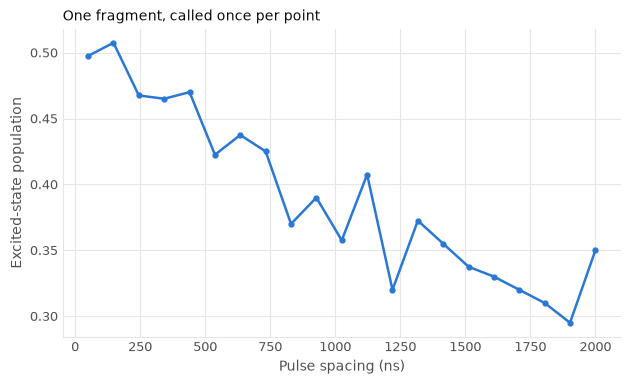

In [9]:
T_DECAY = 12_000.0  # ns, the time constant of the decay the model reports


def decay(bus, env):
    """Population against the total time the train occupies, one wait plus one pulse per step."""
    total_ns = N_PULSES * (env["spacing"] + PULSE_NS)
    return 0.5 * np.exp(-total_ns / T_DECAY)


experiment = qp.QProgram(label="pulse_train_scan")
spacing = experiment.variable("spacing", label="Pulse spacing", units="ns")

with experiment.average(shots=400):
    with experiment.sweep(spacing, qp.Linspace(50, 2000, 21)):
        experiment.call(pulse_train, DRIVE, spacing)
        m_train = experiment.measure(READOUT, "probe", "weights", fields=(MeasurementField.STATE,))

runnable = experiment.expand().with_waveforms(library)
result = qp.simulate(runnable, model=qp.MockMeasurementModel(p_excited=decay, seed=3))

result.plot(m_train, field=MeasurementField.STATE, value=Quantity("Excited-state population"),
            style=Style(markers=True), title="One fragment, called once per point")
plt.show()

## 3.2 Conditionals

Every experiment so far decided everything before the run started. `if_` breaks that, reading a measurement the run has already taken and choosing what happens next while the shot is still in progress.

`program.if_(condition)`, `program.elif_(condition)`, and `program.else_()` are context managers, and the three build one `Conditional` node. The condition is a comparison against a measurement's classified state, so `measure` has to have asked for `MeasurementField.STATE`.

A measurement handle carries a `state` proxy whose `==` builds a comparison rather than answering a bool, which a plain `Variable` cannot do for the reason Basics gave. So the branch reads `if_(handle.state == 1)`. `qp.eq(handle.state, 1)` is accepted too and builds the same node, redundant on a handle where it is the only option on a variable.

In [10]:
PI_NS = 40  # ns, the length of the corrective pulse

chain = qp.QProgram(label="one_chain")
m_chain = chain.measure(READOUT, "probe", "weights", fields=(MeasurementField.STATE,))

with chain.if_(m_chain.state == 1):
    chain.play(DRIVE, "pi")
with chain.elif_(m_chain.state == 0):
    chain.wait(DRIVE, PI_NS)
with chain.else_():
    chain.sync()

print(qp.dumps(chain).split("body:")[1].rstrip())


  measure "q0/readout" "probe" "weights" name="m0" fields=["state"]
  if m0.state == 1:
    play "q0/drive" "pi"
  elif m0.state == 0:
    wait "q0/drive" 40
  else:
    sync


### What a condition may be

One equality or inequality comparison, of one classified state against an integer or against another classified state. Everything else is refused where it is written, with a message naming what arrived instead.

In [11]:
def refuse(label, build):
    """Run a builder that is expected to fail, and print what it said."""
    try:
        build()
    except (qp.ValidationError, TypeError) as exc:
        print(f"{label:24} {type(exc).__name__}: {exc}")


scratch = qp.QProgram(label="refusals")
m_scratch = scratch.measure(READOUT, "probe", "weights", fields=(MeasurementField.STATE,))
counter = scratch.variable("counter")

refuse("two conditions joined", lambda: scratch.if_((m_scratch.state == 1) & (m_scratch.state == 0)))
refuse("a plain variable", lambda: scratch.if_(qp.eq(counter, 1)))
refuse("a float literal", lambda: scratch.if_(m_scratch.state == 1.0))
refuse("an ordered comparison", lambda: scratch.if_(m_scratch.state < 1))

two conditions joined    ValidationError: if_() expects a Comparison condition such as `handle.state == 0` or `handle.state != 1`; got LogicalBinaryOp
a plain variable         ValidationError: if_() condition must reference at least one measurement-state ref (e.g. `handle.state`); got a comparison of Variable and Constant
a float literal          TypeError: handle.state can only be compared to int, another handle.<field>, or a MeasurementRef; got float
an ordered comparison    TypeError: '<' not supported between instances of '_HandleFieldAccess' and 'int'


The chain itself is checked as you write it. An `else_` has to follow an `if_` or an `elif_` at the same nesting level with nothing in between, so an operation written between the two breaks the chain and the `else_` refuses rather than attaching itself to whatever came before.

Two more rules are checked later, because a single line cannot answer them. A conditional reading a measurement that never asked for its state is a `missing-classification` error, and one naming a measurement the program does not contain is `unknown-measurement`. Both come back from `qp.validate` as diagnostics and out of the executor as an exception, and section 3.6 is where diagnostics are read in bulk.

In [12]:
uncalibrated = qp.QProgram(label="no_classification")
m_iq = uncalibrated.measure(READOUT, "probe", "weights")  # fields defaults to the integrated point
with uncalibrated.if_(m_iq.state == 1):
    uncalibrated.play(DRIVE, "pi")

for diagnostic in qp.validate(uncalibrated, qp.reference_capabilities())[0]:
    print(f"[{diagnostic.severity}] {diagnostic.code}")
    print("   ", diagnostic.message)

[error] missing-classification
    Conditional references m0.state, but the measurement does not request state classification (add MeasurementField.STATE to fields=)


### The arm that did not run

A conditional adds no dimension to the result. Every measurement inside it keeps the shape it would have had outside, and the positions where its arm did not run hold `NaN`. Two arms that each measure therefore produce two arrays with complementary holes, and `combine_first` puts them back together. The holes are complementary only while the branch is decided outright at each point, as it is below. Average a point whose outcome is genuinely random and both arms hold a number there, and combining them keeps one and drops the other.

The sweep below hands each arm half of the four points, so the two patterns are easy to read.

In [13]:
split = qp.QProgram(label="two_arms")
level = split.variable("level", label="Herald level", units="DAC units")

with split.sweep(level, qp.Linspace(0.0, 1.0, 4)):
    herald = split.measure(READOUT, "probe", "weights", name="herald", fields=(MeasurementField.STATE,))
    with split.if_(herald.state == 1):
        m_up = split.measure(READOUT, "probe", "weights", name="up", fields=(MeasurementField.STATE,))
    with split.else_():
        m_down = split.measure(
            READOUT, "probe", "weights", name="down", fields=(MeasurementField.STATE,)
        )

# The herald reports an excited qubit only above 0.5, so each arm owns half the sweep.
heralded = qp.MockMeasurementModel(p_excited=lambda bus, env: float(env["level"] >= 0.5))
arms = qp.simulate(split, model=heralded)

up_arm = arms.get(m_up, field=MeasurementField.STATE)
down_arm = arms.get(m_down, field=MeasurementField.STATE)

print("level     ", up_arm.coords["level"].values)
print("if arm    ", up_arm.values)
print("else arm  ", down_arm.values)
print("combined  ", up_arm.combine_first(down_arm).values)
print("dims", up_arm.dims, "so the conditional added no axis")

level      [0.         0.33333333 0.66666667 1.        ]
if arm     [nan nan  1.  1.]
else arm   [ 0.  0. nan nan]
combined   [0. 0. 1. 1.]
dims ('level',) so the conditional added no axis


### Active reset

A qubit does not arrive in the ground state every time. At 40 mK a 4.85 GHz transmon should be excited on well under one shot in a hundred, and real devices come in worse than that, so waiting for those shots to decay costs several times the coherence time on every repetition. Measuring first and flipping only the shots that came back excited is faster, and it is the standard use of a conditional. `P_HOT` below sits far above any real device at 30 percent, so that the before and the after separate at a glance.

The measurement model below carries state, because the second measurement of a shot has to report the qubit the first one found after the corrective pulse has had its chance, and nothing a model receives says which measurement it is answering. A model is any object with a `sample(bus, env)` method, so this is a dozen lines.

In [14]:
P_HOT = 0.30  # the fraction of shots that arrive already excited
RESET_FIDELITY = 0.90  # the probability the corrective pulse lands the qubit in the ground state


class HotQubit:
    """One qubit read out twice per shot, the second read reporting what the first one left.

    The alternation assumes exactly two measurements per shot, in this order. A model is given no
    way to ask which measurement it is answering, so a third `measure` would silently desynchronize
    it. That is the price of putting state in a model.
    """

    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.excited = False
        self.heralding = True

    def sample(self, bus, env):
        if self.heralding:
            self.excited = self.rng.random() < P_HOT  # a fresh shot arrives
        elif self.excited:
            self.excited = self.rng.random() > RESET_FIDELITY  # the corrective pulse fired
        self.heralding = not self.heralding
        return qp.MeasurementSample(i=float(self.excited), q=0.0, state=int(self.excited))


reset = qp.QProgram(label="active_reset")
with reset.average(shots=4000):
    m_before = reset.measure(
        READOUT, "probe", "weights", name="before", fields=(MeasurementField.STATE,)
    )
    with reset.if_(m_before.state == 1):
        reset.play(DRIVE, "pi")
    with reset.else_():
        reset.wait(DRIVE, PI_NS)
    m_after = reset.measure(READOUT, "probe", "weights", name="after", fields=(MeasurementField.STATE,))

reset_run = qp.simulate(reset, model=HotQubit(seed=0))

excited_before = float(reset_run.get(m_before, field=MeasurementField.STATE))
excited_after = float(reset_run.get(m_after, field=MeasurementField.STATE))

print(f"excited before: {excited_before:.3f}   expected {P_HOT:.3f}")
print(f"excited after:  {excited_after:.3f}   expected {P_HOT * (1 - RESET_FIDELITY):.3f}")

excited before: 0.305   expected 0.300
excited after:  0.029   expected 0.030


Thirty percent down to three, in one extra measurement and one conditional pulse per shot. What is left is the reset infidelity, the shots the corrective pulse missed, and improving that is a pulse calibration problem rather than a programming one.

A conditional composes with everything else. A sweep or an average may sit outside it, and either may sit inside an arm, and a conditional may nest inside another.

In [15]:
composed = qp.QProgram(label="conditional_in_a_sweep")
shot = composed.variable("shot")

with composed.average(shots=50):
    with composed.sweep(shot, qp.Range(0, 3, 1)):
        seen = composed.measure(READOUT, "probe", "weights", fields=(MeasurementField.STATE,))
        with composed.if_(seen.state == 1):
            composed.play(DRIVE, "pi")

print(qp.dumps(composed).split("body:")[1].rstrip())


  var shot

  average 50:
    for shot in Range(start=0.0, stop=3.0, step=1.0):
      measure "q0/readout" "probe" "weights" name="m0" fields=["state"]
      if m0.state == 1:
        play "q0/drive" "pi"


## 3.3 A waveform of your own

The shapes the core ships are ordinary Python classes, and so is one you write. A `Waveform` subclass owes exactly two methods. `envelope(resolution=1)` returns the samples, one per `resolution` nanoseconds, and `get_duration()` returns the length in nanoseconds. Everything else is derived on the base class from those two, so `area()`, `peak_amplitude()`, `rms_amplitude()`, `spectrum()`, `plot()`, the notebook rendering, structural equality, and `+` all arrive without being written.

`HalfSine` below is half a sine period, written as a class of its own so the call site names the shape rather than a frequency.

duration: 40 ns in 40 samples
area: 10.673 | peak: 0.42
equal by structure: True


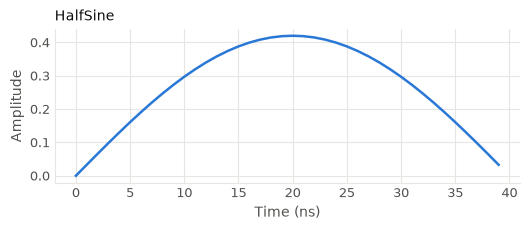

a swept amplitude, before the fix in the next cell: Cannot use ndarray in an Expression; expected Expression, handle.<field>, int, or float


In [16]:
class HalfSine(qp.waveforms.Waveform):
    """Half a period of a sine, from zero up to the amplitude and back to zero."""

    def __init__(self, amplitude: float, duration: int) -> None:
        self.amplitude = amplitude
        self.duration = duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        n = self.duration // resolution
        return self.amplitude * np.sin(np.pi * np.arange(n) / n)

    def get_duration(self) -> int:
        return self.duration


shape = HalfSine(amplitude=0.42, duration=40)

print("duration:", shape.get_duration(), "ns in", shape.envelope().shape[0], "samples")
print("area:", round(shape.area(), 3), "| peak:", round(shape.peak_amplitude(), 3))
print("equal by structure:", HalfSine(0.42, 40) == HalfSine(0.42, 40))

shape.plot()
plt.show()

try:
    probe = qp.QProgram(label="unbound")
    HalfSine(probe.variable("amp"), 40).envelope()
except TypeError as exc:
    print("a swept amplitude, before the fix in the next cell:", exc)

### A parameter a sweep can bind

Put a variable in the amplitude position and it does not arrive as a number. It arrives as a `qp.Expression`, and the arithmetic inside `envelope` meets that instead of a float, so the failure lands at `envelope()` with a message naming neither the waveform nor the variable.

Two changes fix it. Annotate the parameter `float | qp.Expression`, and resolve it at the point of use. Every shape the core ships does this inline, one line per parameter, and the helper below is the same thing factored out so the class stays readable. `get_duration` resolves independently of `envelope`, because the wrapping shapes call it to compare channel lengths.

In [17]:
def resolved(value):
    """A shape parameter's number, evaluated when a sweep has bound it."""
    return value.evaluate_or_raise() if isinstance(value, qp.Expression) else value


class HalfSine(qp.waveforms.Waveform):
    """Half a period of a sine, with both parameters open to a sweep."""

    def __init__(self, amplitude: float | qp.Expression, duration: int | qp.Expression) -> None:
        self.amplitude = amplitude
        self.duration = duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        n = int(resolved(self.duration) / resolution)
        return resolved(self.amplitude) * np.sin(np.pi * np.arange(n) / n)

    def get_duration(self) -> int:
        return int(resolved(self.duration))


try:
    swept = qp.QProgram(label="unbound")
    HalfSine(swept.variable("amp"), 40).envelope()
except qp.UnassignedVariableError as exc:
    print("after the fix: ", exc)

after the fix:  Cannot evaluate expression Variable('amp'): unassigned variable(s) {Variable('amp')}


### Registering it

The class is a working Python object already, and it plays and it draws. Two calls put it in the language.

`qp.register_waveform` adds it to the serialization registry under its class name, so `qp.dumps` writes the constructor and `qp.loads` builds one back. The writer emits the object's public attributes and the parser rebuilds it through `__init__`, and that pairing costs the one constraint the whole seam rests on. The constructor arguments have to *be* the object's state. Store a parameter under a different attribute name, or compute a public attribute the constructor cannot reproduce, and the file is written but no longer loads. Prefix any computed attribute with an underscore.

`qp.register_waveform_token` maps the class to a capability token, so a rack that cannot generate the shape has a name to refuse it by. Without it the shape asks only for `waveform.single`, and any platform accepting single-channel waveforms accepts yours sight unseen.

The serialization registry is global and keyed by class name, so re-running a cell that defines and registers a class raises, the `class` statement having made a new object with a name the registry already holds. There is no unregister, and the guard below is what keeps the cell re-runnable. `register_waveform_token` is idempotent and needs no guard.

In [18]:
try:
    qp.register_waveform(HalfSine)
except ValueError as exc:
    print("already registered in this kernel:", exc)

qp.register_waveform_token(HalfSine, "waveform.half_sine")

flux_scan = qp.QProgram(label="half_sine_scan")
flux_amp = flux_scan.variable("flux_amp", label="Flux amplitude", units="DAC units")
with flux_scan.sweep(flux_amp, qp.Linspace(0.0, 0.5, 5)):
    flux_scan.play("q0/flux", HalfSine(amplitude=flux_amp, duration=40))

text = qp.dumps(flux_scan)
print(text.split("body:")[1].rstrip())
print("\nround trips byte for byte:", qp.dumps(qp.loads(text)) == text)
one_play = qp.operations.Play("q0/flux", HalfSine(0.42, 40))
print("the play now asks for:", sorted(one_play.required_capabilities()))


  var flux_amp label="Flux amplitude" units="DAC units"

  for flux_amp in Linspace(start=0.0, stop=0.5, num=5):
    play "q0/flux" HalfSine(amplitude=flux_amp, duration=40)

round trips byte for byte: True
the play now asks for: ['op.play', 'waveform.half_sine', 'waveform.single']


### The same seam for a sweep source

A sweep source is the second argument of `program.sweep`, and one you write follows the same pattern with one fewer call. A `qp.SweepSource` subclass declares `KIND` and `TOKEN` as class attributes and implements `length()` and `values()`, and its parameters go on public attributes so the text form derives itself the way the waveform's did.

`KIND` is a claim about compilability rather than about the numbers. `"linear"` promises that point $i$ is exactly `start + step * i`, which a platform may compile into one loop register with an increment, and `"arbitrary"` means the values are a table. `TOKEN` is the source's own name, and `qp.register_sweep_source` puts it in the capability registry for you, which is the one asymmetry with a waveform.

`Chebyshev` below crowds its points towards the ends of the interval, the right choice when the interesting structure sits at the edges of a scan rather than in the middle.

In [19]:
class Chebyshev(qp.SweepSource):
    """Chebyshev nodes between two endpoints, so the points crowd towards the edges."""

    KIND = "arbitrary"
    TOKEN = "sweep.chebyshev"

    def __init__(self, start: float, stop: float, num: int) -> None:
        self.start = start
        self.stop = stop
        self.num = num

    def length(self) -> int:
        return self.num

    def values(self) -> np.ndarray:
        k = np.arange(self.num)
        unit = -np.cos(np.pi * (2 * k + 1) / (2 * self.num))
        return self.start + (unit + 1) / 2 * (self.stop - self.start)


try:
    qp.register_sweep_source(Chebyshev)
except ValueError as exc:
    print("already registered in this kernel:", exc)

nodes = Chebyshev(DRIVE_FREQ - 50e6, DRIVE_FREQ + 50e6, 7)
print("values / GHz:", np.round(nodes.values() / 1e9, 4))
print("tokens:      ", sorted(nodes.tokens()))
print("under Repeat:", sorted(qp.Repeat(nodes, times=2).tokens()))

edges = qp.QProgram(label="chebyshev_scan")
edge_freq = edges.variable("freq", label="Drive frequency", units="Hz")
with edges.sweep(edge_freq, Chebyshev(DRIVE_FREQ - 50e6, DRIVE_FREQ + 50e6, 7)):
    edges.set_frequency("q0/drive", edge_freq)

print("\nin a program:", qp.dumps(edges).splitlines()[-2].strip())

values / GHz: [4.8013 4.8109 4.8283 4.85   4.8717 4.8891 4.8987]
tokens:       ['sweep.arbitrary', 'sweep.chebyshev']
under Repeat: ['sweep.arbitrary', 'sweep.chebyshev', 'sweep.repeat']

in a program: for freq in Chebyshev(start=4800000000.0, stop=4900000000.0, num=7):


## 3.4 Vendor packages

A waveform and a sweep source add vocabulary the core could plausibly have shipped. This seam is for vocabulary it must never ship, an operation that means something on one box in one rack and nothing anywhere else.

A vendor extension is a separate Python package that depends on `qprogram` and makes its registration calls at import time. Two are published, each in a repository of its own. `qprogram-qblox` carries the operations and the capability profile of one sequencer of a Qblox cluster, and `qprogram-qdac` does the same for one channel of a QDevil QDAC. Neither opens a socket, so both run on a laptop beside everything else here.

The interesting part is the one thing a package does that a notebook cell cannot. It declares an entry point:

```toml
[project.entry-points."qprogram.vendors"]
qblox = "qprogram_qblox"
```

The name is the vendor namespace and the value is a module that self-registers on import, and `qprogram.vendors` is the only group scanned. So a `.qp` file that names the extensions it needs in its own header loads in a fresh interpreter without the reader knowing what to import.

Nothing in this notebook has imported `qprogram_qblox` yet, so the first line reads `False`, and it does so only the first time the cell runs in a kernel. Both lines are facts about this interpreter rather than about the file.

In [20]:
FROM_A_COLLEAGUE = """#!QProgram 0.2

require qblox 0.2

body:
  qblox.set_markers "q0/drive" "0001"
"""

print("qprogram_qblox imported before the load:", "qprogram_qblox" in sys.modules)
delivered = qp.loads(FROM_A_COLLEAGUE)
print("qprogram_qblox imported after the load: ", "qprogram_qblox" in sys.modules)
print("the operation came back as:", qp.dumps(delivered).splitlines()[-1].strip())

qprogram_qblox imported before the load: False
qprogram_qblox imported after the load:  True
the operation came back as: qblox.set_markers "q0/drive" "0001"


### What the two packages add

Each one registers a namespace reached as an attribute of any program, and a profile that says what the instrument can do. The two disagree about one operation. A Qblox bus changes its offset between one pulse and the next, so `qblox-default-v1` claims the core `op.set_offset`. A QDAC channel takes every change through the host at millisecond latency, so `qdac-default-v1` refuses that token and offers `vendor.qdac.set_offset` in its place, because borrowing a core name whose semantics do not fit would make the two look interchangeable.

In [21]:
import qprogram_qblox  # noqa: F401  registers the qblox namespace and its profile
import qprogram_qdac  # noqa: F401  registers the qdac namespace and its profile

for vendor in ("qblox", "qdac"):
    namespace = getattr(qp.QProgram(), vendor)
    print(f"program.{vendor}:", sorted(m for m in dir(namespace) if not m.startswith("_")))

print()
for name in ("qprogram-base-v1", "qblox-default-v1", "qdac-default-v1"):
    profile = qp.CompilerCapabilities.from_profile(name)
    print(f"{name:18} {len(profile.capabilities):2d} tokens, limits {profile.limits}")

print()
qblox_half = qp.CompilerCapabilities.from_profile("qblox-default-v1")
qdac_half = qp.CompilerCapabilities.from_profile("qdac-default-v1")
for token in ("op.set_offset", "vendor.qdac.set_offset", "waveform.iq"):
    print(f"{token:24} qblox {qblox_half.supports(token)!s:5} qdac {qdac_half.supports(token)}")

program.qblox: ['acquire', 'set_acquisition_rotation', 'set_acquisition_threshold', 'set_markers', 'set_trigger', 'wait_trigger']
program.qdac: ['play', 'set_offset', 'set_trigger', 'wait_trigger']

qprogram-base-v1   33 tokens, limits {}
qblox-default-v1   31 tokens, limits {'min_wait_duration_ns': 4}
qdac-default-v1    16 tokens, limits {'min_dwell_ns': 100}

op.set_offset            qblox True  qdac False
vendor.qdac.set_offset   qblox False qdac True
waveform.iq              qblox True  qdac False


A program reaches a vendor operation through the namespace, and the header grows one `require` line per vendor it uses, sorted, with the patch component truncated because a patch release changes code and never the wire form.

The mixins below exist for static typing and editor autocompletion. `program.qdac.set_offset` resolves without them, and a control library that already depends on several extensions normally ships the combined class so its users never write this.

In [22]:
from qprogram.waveforms import Ramp
from qprogram_qblox import QbloxMixin
from qprogram_qdac import QdacMixin

FLUX_BIAS = 0.42  # V, the DC level the QDAC channel holds on the flux line


class RackProgram(QbloxMixin, QdacMixin, qp.QProgram):
    """One builder with both vendor namespaces typed for the editor."""


mixed = RackProgram(label="bias_then_acquire")
mixed.qdac.set_offset("q0/flux", FLUX_BIAS)
mixed.qdac.play("q0/flux", Ramp(0.0, 0.3, 400), dwell=200)
mixed.qblox.acquire(READOUT, "weights")

print(qp.dumps(mixed))

#!QProgram 0.2

require qblox 0.2
require qdac 0.2

metadata:
  label: "bias_then_acquire"

body:
  qdac.set_offset "q0/flux" 0.42
  qdac.play "q0/flux" Ramp(from_amplitude=0.0, to_amplitude=0.3, duration=400) dwell=200
  qblox.acquire "q0/readout" "weights" name="m0"



Three ways for a `require` line to fail, and each one names the problem rather than dropping an operation on the floor. A vendor nobody claims has no entry point to find, and the message says which package to install. A version above the installed one is refused, because the operation the file needs may not exist yet. A version carrying a patch component is refused rather than rounded down, because a writer never puts one there.

In [23]:
for label, header in (
    ("a vendor nobody claims", "require acme_rack 0.1"),
    ("a version this install is too old for", "require qdac 0.9"),
    ("a patch component the line cannot carry", "require qdac 0.2.0"),
):
    try:
        qp.loads(f'#!QProgram 0.2\n\n{header}\n\nbody:\n  wait "q0/drive" 100\n')
    except qp.ParseError as exc:
        print(f"{label}:\n  {exc}\n")

a vendor nobody claims:
  Line 3: file requires vendor 'acme_rack' 0.1 but no matching extension is registered in this environment — install the package that declares the 'qprogram.vendors' entry point for 'acme_rack', or import the extension before loading

a version this install is too old for:
  Line 3: file requires qdac 0.9, newer than the installed qdac 0.2.0 — install qdac 0.9 or newer

a patch component the line cannot carry:
  Line 3: file version '0.2.0' must be exactly major.minor



A version below the installed one is the case that loads. A release that changes a syntax registers a rewrite for it, and reading applies every rewrite between the version on the line and the installed one, oldest first, to the lines in memory. The file on disk is never touched, and writing the program back out writes today's version. So the chain holds one entry per breaking change rather than one per release, and `qp.serialization.known_migrations` lists what a format has registered. Nothing is registered yet, so the file below announces `0.1` in its header and in its `require` line, loads unchanged, and comes back as `0.2` on both.

In [24]:
FROM_LAST_YEAR = """#!QProgram 0.1

require qdac 0.1

body:
  qdac.set_offset "q0/flux" 0.42
"""

print("registered migrations:", qp.serialization.known_migrations("qp") or "none")
lines = qp.dumps(qp.loads(FROM_LAST_YEAR)).splitlines()
print("goes back out as:", [line for line in lines if line.startswith(("#!", "require"))])

registered migrations: none
goes back out as: ['#!QProgram 0.2', 'require qdac 0.2']


### Your own namespace

Two classes and four calls. An `Operation` subclass is the node that lands in the tree, and it owes only `required_capabilities()`, with `variables()`, `buses()`, `waveforms()`, `walk()`, and structural equality all coming from the base. A `qp.VendorNamespace` subclass is the method surface, where `self._append` puts a node into the program being built.

The operation below sets the pump tone of a parametric amplifier, one box on the 10 mK stage and the first amplifier the readout tone meets on the way out. It belongs in nobody's vendor-agnostic language, and the seam exists for exactly that.

`register_vendor_version` goes last on purpose. Registering the version marks a vendor active, so it doubles as the flag `qp.try_activate_vendor` reads and makes the whole block re-runnable with one guard. The two class definitions sit inside that guard for the same reason: re-running a cell that defines a class makes a new class object, the registry would still point at the old one, and `qp.dumps` would then meet a node it does not recognise.

In [25]:
PUMP_FREQ = 7.9e9  # Hz, the pump tone that gives this amplifier its best gain


if qp.try_activate_vendor("twpa"):
    print("twpa is already registered in this kernel, nothing to do")
else:

    class SetPump(qp.operations.Operation):
        """A host-side write of the amplifier pump tone on one readout line."""

        def __init__(self, bus: str, frequency: float | qp.Expression) -> None:
            self.bus = bus
            self.frequency = frequency

        def required_capabilities(self) -> set[str]:
            return {"vendor.twpa.set_pump"} | qp.protocol.expression_tokens(self.frequency)

    class TwpaNamespace(qp.VendorNamespace):
        """The methods reached as program.twpa.<operation>()."""

        def set_pump(self, bus: str, frequency: float | qp.Expression) -> None:
            self._append(SetPump(bus=bus, frequency=frequency))

    qp.QProgram.register_vendor("twpa", TwpaNamespace)  # on the base class, never on a mixin
    qp.register_vendor_operation("twpa", "set_pump", SetPump)
    qp.register_capability_tokens("vendor.twpa.set_pump")
    qp.register_vendor_version("twpa", "0.1.0")  # last, so the guard above sees a complete block
    print("twpa registered")

pumped = qp.QProgram(label="pump_then_read")
pumped.twpa.set_pump(READOUT, PUMP_FREQ)
pump_text = qp.dumps(pumped)

print()
print(pump_text)
print("round trips byte for byte:", qp.dumps(qp.loads(pump_text)) == pump_text)

twpa registered

#!QProgram 0.2

require twpa 0.1

metadata:
  label: "pump_then_read"

body:
  twpa.set_pump "q0/readout" 7900000000.0

round trips byte for byte: True


## 3.5 Implementing a platform

Everything you have run so far went through `qp.ReferencePlatform`. A vendor platform is the same interface with a compiler behind it, and the interface asks for six members and offers four.

| Member | What it answers |
|---|---|
| `get_bus_schema()` | which chip this rack is wired to |
| `get_buses()` | the bus names it exposes |
| `get_parameters(bus)` | the knobs on one bus |
| `get_global_parameters()` | the knobs that belong to no bus |
| `capabilities` | what it can and cannot run, as tokens, limits, and predicates |
| `execute(program)` | run it and return a `QProgramResult` |

Those six are abstract. `validate`, `plan`, and `explain` arrive already written, the first two delegating to the core validator and the third to the plan renderer, so a platform gets section 3.6's diagnostics without writing any. `stream` is the one member a platform may leave alone, and its default raises.

One convention is documented rather than enforced. `execute` validates first, raises `qp.UnsupportedOperationError` on any error diagnostic, and surfaces warnings without raising. Skipping the check means a reader gets a compiler backtrace where a structured diagnostic was available.

In [26]:
print("must implement:", sorted(qp.PlatformProtocol.__abstractmethods__))

must implement: ['capabilities', 'execute', 'get_bus_schema', 'get_buses', 'get_global_parameters', 'get_parameters']


### A rack, start to finish

`BenchtopRack` below is a complete platform. It answers the four resource questions from a schema and a parameter dictionary, it holds a capability descriptor built once, and its `execute` follows the convention line for line.

The last line of `execute` is the seam. A real platform compiles the tree for its own instruments there, uploads it, runs it, and assembles the arrays. That work is where a vendor's expertise lives and the protocol deliberately says nothing about it. This one borrows the reference interpreter instead, so the cell shows the six members rather than a compiler.

In [27]:
schema = BusSchema.flux_tunable_transmon()
q = schema.q


class BenchtopRack(qp.PlatformProtocol):
    """One flux-tunable qubit, with the flux line on a slow DAC and no real-time half."""

    def __init__(self, schema, capabilities, parameters=None):
        self._schema = schema
        self._capabilities = capabilities
        self.parameters = dict(parameters or {})

    def get_bus_schema(self):
        return self._schema

    def get_buses(self):
        return [f"q0/{kind}" for kind in self._schema.elements["q"].buses]

    def get_parameters(self, bus):
        return sorted(key.split(".", 1)[1] for key in self.parameters if key.startswith(f"{bus}."))

    def get_global_parameters(self):
        return ["fridge_temperature"]

    @property
    def capabilities(self):
        return self._capabilities

    def execute(self, program):
        diagnostics, _ = qp.validate(program, self._capabilities)
        errors = [d for d in diagnostics if d.severity == "error"]
        if errors:
            raise qp.UnsupportedOperationError(
                "BenchtopRack cannot run this program:\n" + "\n".join(str(d) for d in errors)
            )
        for diagnostic in diagnostics:
            if diagnostic.severity == "warning":
                warnings.warn(str(diagnostic), qp.ExecutionWarning, stacklevel=2)
        # A real rack compiles, uploads and acquires here. This one borrows the interpreter.
        return qp.ReferencePlatform(self._schema, parameters=self.parameters).execute(program)


print("still abstract:", sorted(BenchtopRack.__abstractmethods__) or "nothing, all six are implemented")

still abstract: nothing, all six are implemented


The program it runs steps a flux bias and reads the qubit out at every point. The flux line is the one this rack drives with a slow DAC, and taking the real-time half of the flux slot away from an otherwise permissive descriptor is how that gets written down. A descriptor holds one capability slot per kind of bus, each slot a real-time half named `rt` and a host half named `host`, and section 3.6 takes the shape apart in full. All this cell needs is that `rt=None` on the flux slot means nothing on that line can run a loop in real time. `dataclasses.replace` on a frozen descriptor is the shortest way to record a machine that differs from one you already have.

In [28]:
def flux_sweep(label="flux_sweep"):
    """One flux bias scan, averaged, with an explicit sync target list."""
    program = qp.QProgram(label=label, schema=schema)
    bias = program.variable("bias", label="Flux bias", units="V")
    with program.average(shots=200):
        with program.sweep(bias, qp.Linspace(BIAS_START, BIAS_STOP, BIAS_POINTS)):
            program.set_offset(q[0].flux, bias)
            program.set_frequency(q[0].drive, DRIVE_FREQ)
            program.play(q[0].drive, "pi")
            program.sync([q[0].drive, q[0].readout])
            program.measure(
                q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,)
            )
    return program


reference = qp.reference_capabilities()
slow_dac = replace(reference.default_bus_profile, rt=None)  # a flux line with no real-time half
rack_caps = replace(reference, bus={("q", "flux"): slow_dac})

rack = BenchtopRack(schema, rack_caps, parameters={"q0/flux.dac_range": 0.5})
sweep = flux_sweep()

print("buses:               ", rack.get_buses())
print("knobs on q0/flux:    ", rack.get_parameters(q[0].flux))
print("knobs on no bus:     ", rack.get_global_parameters())

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    run = rack.execute(sweep)

print("result:              ", run)
population = run.get("m0", field=MeasurementField.STATE)
print("array:               ", population.dims, population.shape)
print("warning it surfaced: ", caught[0].message)

buses:                ['q0/drive', 'q0/readout', 'q0/flux']
knobs on q0/flux:     ['dac_range']
knobs on no bus:      ['fridge_temperature']


result:               QProgramResult(1 measurements, names=['m0'])
array:                ('bias',) (41,)
warning it surfaced:  [warning] forced-host: Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep'. (at body[0])


A real result with a real array comes back, and the warning is reported rather than swallowed. The `catch_warnings` block is only there so the text appears in the cell output instead of on standard error.

Take the operation away entirely and the same platform refuses the program before anything runs, with the missing capability named and the path to the node that wanted it.

In [29]:
host_half = reference.default_bus_profile.host
dc_source = replace(host_half, profile="dc-source-v1",
                    capabilities=host_half.capabilities - {"op.set_offset"})
fixed_caps = replace(reference, bus={("q", "flux"): qp.BusCapabilities(rt=None, host=dc_source)})

try:
    BenchtopRack(schema, fixed_caps).execute(sweep)
except qp.UnsupportedOperationError as exc:
    print(f"{type(exc).__name__}: {exc}")

UnsupportedOperationError: BenchtopRack cannot run this program:
[error] missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source-v1' (host) (at body[0][0][0])


### What comes free, and where the arrays come from

`BenchtopRack` implements none of the three, and all three answer.

In [30]:
for diagnostic in rack.validate(sweep):
    print(f"{diagnostic.severity:8} {diagnostic.code}")
print("plan entries:", len(rack.plan(sweep)))

warning  forced-host
info     reorderable-averaging
plan entries: 7


The one thing borrowing the interpreter hid is where a result comes from, so here it is. A `qp.QProgramResult` is built empty and filled one measurement at a time with `append_measurement(bus=, name=, data=)`, where `data` is an `xarray.DataArray` the platform assembles itself. Omitting `fields=` records the array under the integrated-point field, which is the one `result.get` returns by default.

The subclass below overrides `execute` and returns arrays of zeros with the right shape and the right coordinates. Its first three lines are shape bookkeeping, the part a real compiler already knows from its own upload, and that is why the delegating version above reads better as a platform.

In [31]:
class ArrayRack(BenchtopRack):
    """The same rack, assembling its own result instead of borrowing an interpreter."""

    def execute(self, program):
        axes = {loop.variable.id: loop.source.values()
                for loop in program.body.walk() if isinstance(loop, qp.blocks.Sweep)}
        shape = tuple(len(values) for values in axes.values())
        result = qp.QProgramResult()
        for node in program.body.walk():
            if isinstance(node, qp.operations.Measure):
                data = xr.DataArray(np.zeros(shape), dims=tuple(axes), coords=axes)
                result.append_measurement(bus=node.bus, name=node.handle.name,
                                          data=data, fields={MeasurementField.STATE.value: data})
        return result


own = ArrayRack(schema, rack_caps).execute(sweep)
state = own.get("m0", field=MeasurementField.STATE)

print("result:    ", own)
print("array:     ", state.dims, state.shape)
print("bias coord:", np.round(state.coords["bias"].values[:3], 3), "...")

result:     QProgramResult(1 measurements, names=['m0'])
array:      ('bias',) 

(41,)
bias coord: [-0.05  -0.045 -0.04 ] ...


`qp.ReferencePlatform` takes four arguments and every one of them is a seam of its own. `schema` is the object `get_bus_schema` returns. `model` is the measurement model, defaulting to a fresh mock that keeps every shot in the ground state. `parameters` seeds the platform parameter store, one flat dictionary keyed `"bus.parameter"` that `get_parameter` reads and `set_parameter` writes, and writes persist across calls to `execute` on the same platform. `vendor_op_handlers` maps a vendor operation class to a callback, so a vendor's own parameter operations get a runtime effect.

`qp.simulate` is one line over all of it, a throwaway `ReferencePlatform` and one `execute`.

In [32]:
bench = qp.ReferencePlatform(schema=schema, parameters={"q0/drive.attenuation": 20.0})

read_back = qp.QProgram(label="parameter_store", schema=schema)
read_back.set_parameter(q[0].flux, "bias", 0.05)
attenuation = read_back.get_parameter(q[0].drive, "attenuation")
bench.execute(read_back)

print("seeded and then written:", bench.parameters)
print("read back into a variable:", attenuation.id, "=", attenuation.value)

seeded and then written: {'q0/drive.attenuation': 20.0, 'q0/flux.bias': 0.05}
read back into a variable: q0_drive_attenuation = 20.0


## 3.6 Capabilities, plans, and rewrites

A capability descriptor is where a machine writes down what it can run, the object a platform hands the validator, and this section takes one apart.

A `qp.PlatformCapabilities` has three fields. `bus` is a mapping keyed by the pair of element kind and bus kind, so `("q", "flux")` is a separate entry from `("q", "drive")`. `platform` answers for whatever names no bus, meaning the blocks and the expressions. `default_bus_profile` answers for every bus slot the map does not list, a plain string bus included, since a plain string carries no schema coordinate to route on.

Every one of those three is a `qp.BusCapabilities`, a pair of an `rt` half and a `host` half, where `rt` is whatever in the machine runs a sequence on its own clock, a sequencer for instance, and `host` is the control PC, and either half may be `None`. Each half is a `qp.CompilerCapabilities` with six fields: a `profile` name, a `version`, a set of `capabilities` tokens, a mapping of `limits`, a tuple of `predicates`, and the `vendor_versions` it implements.

In [33]:
schema = BusSchema.flux_tunable_transmon()
q = schema.q
reference = qp.reference_capabilities()

print("per-bus map:      ", dict(reference.bus), "so every bus falls through")
print("platform slot:    ", reference.platform.rt.profile, reference.platform.rt.version)
print("default bus slot: ", reference.default_bus_profile.rt.profile)
print("domains filled:   ", sorted(reference.default_bus_profile.supported_domains()))
bus_slot = reference.default_bus_profile
print("host can do, rt cannot:", sorted(bus_slot.host.capabilities - bus_slot.rt.capabilities))

per-bus map:       {} so every bus falls through
platform slot:     qprogram-reference-platform (0, 1, 0)
default bus slot:  qprogram-reference-bus
domains filled:    ['host', 'rt']
host can do, rt cannot: ['op.get_parameter', 'op.set_parameter']


Those two operations are the one asymmetry the reference descriptor builds in. A parameter write is a setting the platform holds as configuration rather than a property of the bus a run can change, so it is host-side on every bus even on the most permissive machine in the library.

What picks a slot is the node rather than the token. A block goes to the platform slot. An operation that touches a bus goes to that bus's slot, and one that touches several is checked against the intersection. One prefix routes on its own: every `expr.*` token goes to the platform slot even on an operation that does touch a bus, because it is a claim about the language rather than about the line.

The demand side is one call on any node, and the supply side is one hash lookup.

In [34]:
bias_sweep = qp.QProgram(label="flux_sweep", schema=schema)
sweep_bias = bias_sweep.variable("bias", label="Flux bias", units="V")
with bias_sweep.average(shots=200):
    with bias_sweep.sweep(sweep_bias, qp.Linspace(BIAS_START, BIAS_STOP, BIAS_POINTS)):
        bias_sweep.set_offset(q[0].flux, sweep_bias)
        bias_sweep.set_frequency(q[0].drive, DRIVE_FREQ)
        bias_sweep.play(q[0].drive, "pi")
        bias_sweep.sync([q[0].drive, q[0].readout])
        bias_sweep.measure(q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,))

for node in bias_sweep.body.walk():
    if node is not bias_sweep.body:  # walk() yields the root block first
        print(f"{type(node).__name__:14} {sorted(node.required_capabilities())}")

Average        ['block.average']
Sweep          ['block.sweep', 'sweep.linear', 'sweep.linspace']
SetOffset      ['expr.variable', 'op.set_offset']
SetFrequency   ['op.set_frequency']
Play           ['op.play', 'waveform.alias']
Sync           ['op.sync']
Measure        ['measure.fields.state', 'op.measure', 'waveform.alias', 'waveform.iq']


In [35]:
flux_slot = reference.for_bus(q[0].flux)
for token in ("op.set_offset", "op.set_parameter"):
    print(f"{token:18} rt={flux_slot.rt.supports(token)!s:6} host={flux_slot.host.supports(token)}")

op.set_offset      rt=True   host=True
op.set_parameter   rt=False  host=True


### A published profile

Writing a descriptor by editing the reference one describes no real machine and changes every time somebody installs a package. A shipped extension publishes a `qp.Profile` instead, a named and versioned bundle of tokens, limits, and predicates, and `qp.CompilerCapabilities.from_profile` resolves one by name.

Four fields do most of the work. `extends` names a parent, and the child accumulates the parent's tokens and predicates while overriding its limits. `qprogram-base-v1` is the core bundle, and it carries blocks, expressions, and sweeps and no bus operation at all, exactly the shape a platform slot wants. So a profile that needs the core plus one thing declares only the difference.

Registration is idempotent for an equal profile, and predicates compare as objects, so hold them as module-level functions rather than lambdas or a cell rebuilding the profile raises.

In [36]:
qp.register_capability_tokens("vendor.benchtop.dac_ramp")
BENCHTOP_FLUX = qp.Profile(
    name="benchtop-flux-v1",
    version=(1, 0, 0),
    extends="qprogram-base-v1",
    capabilities=frozenset({"op.set_offset", "op.wait", "vendor.benchtop.dac_ramp"}),
    limits={"max_loop_nesting": 2},
)
qp.register_profile(BENCHTOP_FLUX)

base = qp.CompilerCapabilities.from_profile("qprogram-base-v1")
merged = qp.CompilerCapabilities.from_profile("benchtop-flux-v1")

print("qprogram-base-v1 :", len(base.capabilities), "tokens, and no bus operation at all")
print("benchtop-flux-v1 :", len(merged.capabilities), "tokens, the parent plus its own three")
print("inherited        :", merged.supports("block.sweep"))
print("its own          :", merged.supports("op.set_offset"))
print("limits           :", merged.limits)

qprogram-base-v1 : 33 tokens, and no bus operation at all
benchtop-flux-v1 : 36 tokens, the parent plus its own three
inherited        : True
its own          : True
limits           : {'max_loop_nesting': 2}


### `qp.validate`

`qp.validate(program, capabilities)` reads a program against a descriptor and hands back a tuple of the diagnostics and the plan, whatever it finds, and it raises nothing. One call then serves callers who want different things out of a failure: an editor plugin that wants every diagnostic and no exceptions, a continuous-integration job that wants a non-zero exit, a notebook that wants to keep going and show the plan. A platform's `execute` is the caller that turns an error into an exception.

The plan maps each node to the set of domains it will run in. A `qp.Diagnostic` carries eight fields, and the two you act on are `severity` and `code`. Do not print a diagnostic list directly, because a `Diagnostic` holds the offending node and its repr is an object address.

In [37]:
clean, plan = qp.validate(bias_sweep, reference)
print("clean run:", clean, "| plan entries:", len(plan))
print()

reference_bus = reference.default_bus_profile
slow_dac = replace(reference_bus, rt=None)  # a flux line with no real-time half
rack_caps = replace(reference, bus={("q", "flux"): slow_dac})

for diagnostic in qp.validate(bias_sweep, rack_caps)[0]:
    print(f"[{diagnostic.severity}] {diagnostic.code}")

clean run: [] | plan entries: 7

[warning] forced-host
[info] reorderable-averaging


In [38]:
host_half = reference_bus.host
dc_source = replace(host_half, profile="dc-source-v1",
                    capabilities=host_half.capabilities - {"op.set_offset"})
fixed_caps = replace(reference, bus={("q", "flux"): qp.BusCapabilities(rt=None, host=dc_source)})

refusal = qp.validate(bias_sweep, fixed_caps)[0][0]
print("severity:  ", refusal.severity)
print("code:      ", refusal.code)
print("message:   ", refusal.message)
print("node:      ", type(refusal.node).__name__)
print("path:      ", refusal.path, "which reads", qp.format_path(refusal.path))
print("capability:", refusal.capability)
print("domain:    ", refusal.domain)

severity:   error
code:       missing-capability
message:    'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source-v1' (host)
node:       SetOffset
path:       (0, 0, 0) which reads body[0][0][0]
capability: op.set_offset
domain:     host


The `message` is for a terminal, the `code` is for a script deciding whether a build should fail, and the `path` is for an editor putting a squiggle under the right line. `qp.format_path` prints one, `qp.node_path` and `qp.resolve_path` walk between a path and its node in either direction, and `program.source_map` turns a path into a line number on a program that came through `qp.loads`.

### `qp.explain`

The same plan, drawn. One `.qp` line per node, the domains it will run in on the right, and any diagnostic beside it. Four values appear in the domain column: both domains, one of them, or neither. Annotations sit inline at the end of a row, so a block carrying two of them produces a row long enough to wrap on any screen.

In [39]:
print(qp.explain(bias_sweep, reference))

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ average 200:                                                             [rt|host]
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [rt|host]
      ├─ set_offset q[0].flux bias                                          [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


Every row reads both domains, because the reference platform supports the whole language.

Now the rack whose flux line has no real-time half. Nothing in the program changed and its plan did.

In [40]:
print(qp.explain(bias_sweep, rack_caps))

plan for 'flux_sweep' — errors: 0 · warnings: 1 · info: 1
body
└─ average 200:                                                             [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'  i reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize().
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [host]
      ├─ set_offset q[0].flux bias                                          [host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0

`set_offset` routes to the flux slot, which has a host half only, so the operation is host-side, the sweep holding it went host-side, and the averaging above that followed. The `forced-host` warning reports exactly that, naming the block that fell and the child that pulled it. Severity is what you act on here, and a warning still runs: what fell is the averaging, so the round trip is paid two hundred times per bias point instead of once.

The second annotation is the validator saying it can see a cheaper arrangement of the same experiment, and the rewrite it points at closes the section.

Take the operation away instead of its real-time half, and the row reads as running nowhere.

In [41]:
print(qp.explain(bias_sweep, fixed_caps))

plan for 'flux_sweep' — errors: 1 · warnings: 0 · info: 0
body
└─ average 200:                                                             [rt|host]
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [--]
      ├─ set_offset q[0].flux bias                                          [--]       !! missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source-v1' (host)
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


Read that tree from the leaves up. The `set_offset` row runs nowhere and the diagnostic sits beside it. The sweep above it runs nowhere either and carries nothing of its own, because an operation that can run nowhere empties the loop holding it, so looking on the loop's own line for a reason will not find one. The averaging at the top still reads both domains, because an empty child propagates exactly one level and then stops.

### Limits

`capabilities` was the token set. `limits` are numbers a program is measured against, and the validator reads exactly four keys and passes over every other one. `max_loop_nesting`, `max_parallel_loops`, and `max_measurements` come off the platform slot, and `min_wait_duration_ns` off the bus a `wait` routes to. A profile may publish a key outside that set, and `qdac-default-v1` does, so publishing a limit and enforcing it are two different things.

Within a slot the limits are read from one half only, the real-time half when the slot has one. A limit declared only on the host half of a slot that also has a real-time half is never read, and the result is an empty diagnostics list that reads like a passing program.

In [42]:
def platform_limits(limits):
    """The reference descriptor with one set of limits on its platform slot."""
    platform_rt = replace(reference.platform.rt, limits=limits)
    return replace(reference, platform=replace(reference.platform, rt=platform_rt))


for limits in ({"max_loop_nesting": 1}, {"max_measurements": 0}):
    print(qp.validate(bias_sweep, platform_limits(limits))[0][0])

on_the_wrong_half = replace(reference, platform=replace(
    reference.platform, host=replace(reference.platform.host, limits={"max_loop_nesting": 1})))
print("the same limit on the host half:", qp.validate(bias_sweep, on_the_wrong_half)[0] or "not read")

[error] limit-exceeded: Program nests loops 2 deep; limit max_loop_nesting=1
[error] limit-exceeded: Program contains 1 measurements; limit max_measurements=0
the same limit on the host half: not read


### Predicates

The third field a descriptor carries is a tuple of callables. A predicate receives a node and a `qp.ValidationContext`, and it yields nothing when the node is fine. What it yields otherwise is one of two things.

A `qp.Diagnostic` is a hard no. The rule below is about a bench rather than about an instruction set. This rack's flux DAC will not go past a tenth of a volt, and a predicate is where that number gets written down. The context is why the rule is expressible at all, because the value being written is a variable and the numbers live in the loop that binds it, a different node several levels up. `ctx.binding_loop_of(variable)` finds that loop and `loop.source.values()` is its own numbers.

Eight queries make up the context, and `binding_loop_of` and `sweep_kind_of` are the two the shipped predicates use. The others report the deepest loop nesting, the widest lockstep composition, the measurement count, the fields one measurement asked for, every measurement name, and every bus the program touches. `ctx.sweep_kind_of(variable)` answers whether a variable is swept linearly, arbitrarily, or not at all, so a rack can refuse an arbitrary list of delays behind a `wait` without refusing every arbitrary sweep it has.

In [43]:
BIAS_LIMIT = 0.1  # V, the most this rack's flux DAC will put on a line


def with_predicate(slot, predicate):
    """One capability slot with a predicate added to each half that exists."""
    def add(half):
        return None if half is None else replace(half, predicates=(*half.predicates, predicate))
    return qp.BusCapabilities(rt=add(slot.rt), host=add(slot.host))


def flux_within_range(node, ctx):
    """Refuse a flux sweep that leaves the DAC's range."""
    if isinstance(node, qp.operations.SetOffset) and isinstance(node.offset_path0, qp.Variable):
        loop = ctx.binding_loop_of(node.offset_path0)
        if loop is not None:
            reach = max(abs(loop.source.values()))
            if reach > BIAS_LIMIT:
                yield qp.Diagnostic(
                    severity="error",
                    code="benchtop.flux-out-of-range",
                    message=f"flux sweep reaches {reach:.2f} V, past this DAC's {BIAS_LIMIT} V",
                    node=node,
                )


guarded = replace(reference, bus={("q", "flux"): with_predicate(reference_bus, flux_within_range)})

print(qp.validate(bias_sweep, guarded)[0][0])

narrow = qp.QProgram(label="narrow_scan", schema=schema)
narrow_bias = narrow.variable("bias", label="Flux bias", units="V")
with narrow.sweep(narrow_bias, qp.Linspace(-0.05, 0.05, 11)):
    narrow.set_offset(q[0].flux, narrow_bias)
print("a scan inside the range:", qp.validate(narrow, guarded)[0] or "no diagnostics")

[error] benchtop.flux-out-of-range: flux sweep reaches 0.15 V, past this DAC's 0.1 V (at body[0][0][0])
a scan inside the range: no diagnostics


The other thing a predicate may yield is a `qp.DomainConstraint`. It is the answer when the truth is not a refusal but "not in real time, and the host can do it". It names the block to restrict, the domains to take away, and a reason, and the classifier subtracts that domain from the loop rather than failing the program. The reason comes back inside the warning.

The node has to be a block rather than the operation that noticed, and the binding loop is the block worth naming, because the fallback is about a loop's iteration mechanism and an operation has none. Point one at an operation and the validator answers with an error of its own.

One difference from taking a half away is worth seeing. Under a constraint the operation itself still supports both domains and only the loop is restricted, where a slot with no real-time half makes the operation host-side too. The two look the same on the block and differ on the operation, and that difference decides whether the rewrite below can help.

In [44]:
def dac_on_the_network(node, ctx):
    """Not a refusal. The loop that steps this DAC has to dispatch from the host."""
    if isinstance(node, qp.operations.SetOffset) and isinstance(node.offset_path0, qp.Variable):
        if ctx.sweep_kind_of(node.offset_path0) is not None:
            yield qp.DomainConstraint(
                node=ctx.binding_loop_of(node.offset_path0),
                exclude=frozenset({"rt"}),
                reason="the flux DAC answers over the network",
            )


networked = replace(reference, bus={("q", "flux"): with_predicate(reference_bus, dac_on_the_network)})
print(qp.explain(bias_sweep, networked))

plan for 'flux_sweep' — errors: 0 · warnings: 1 · info: 0
body
└─ average 200:                                                             [host]     ~ forced-host: contains host-side-only sub-block 'Sweep' (the flux DAC answers over the network)
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [host]
      ├─ set_offset q[0].flux bias                                          [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


### `qp.optimize`

Back to the rack whose flux line has no real-time half, where the averaging fell host-side because it *encloses* the flux sweep while everything it averages runs in real time. Swapping the two loops removes the reason, and `qp.optimize(program, capabilities)` is the swap. It returns a new program and never mutates the one it was given.

In [45]:
regrouped = qp.optimize(bias_sweep, rack_caps)
print(qp.explain(regrouped, rack_caps))

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                    [host]
   ├─ set_offset q[0].flux bias                                             [host]
   └─ average 200:                                                          [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


The sweep is the outer block now, the `set_offset` has been hoisted to sit between the two, and the averaging is back in real time with no warning left.

The rewrite is opt-in, because it is not unconditionally equivalent. It takes all two hundred shots of one bias point before moving on, where the program as written interleaved passes over the whole sweep. The two are the same experiment for a stationary device and different under drift, so when you want the interleaving, do not call it. The hoisted `set_offset` also runs once per bias point rather than once per shot, right for a DC level and wrong for an operation with side effects. The rewrite therefore hoists only a leading run of host-side-only operations, and it refuses to move one past an operation it would reorder against.

The pattern it matches is narrow, and the hint in the plan is how you find out in advance. The hint and the rewrite read the same test, so they cannot disagree: no hint, no change.

In [46]:
def hinted(program, capabilities):
    """The reorderable-averaging codes in one plan, which is one entry or none."""
    return [d.code for d in qp.validate(program, capabilities)[0] if d.code == "reorderable-averaging"]


nested = qp.QProgram(label="two_sweeps", schema=schema)
nested_bias = nested.variable("bias", label="Flux bias", units="V")
nested_freq = nested.variable("freq", label="Drive frequency", units="Hz")
with nested.average(shots=200):
    with nested.sweep(nested_bias, qp.Linspace(BIAS_START, BIAS_STOP, 11)):
        nested.set_offset(q[0].flux, nested_bias)
        with nested.sweep(nested_freq, qp.Linspace(DRIVE_FREQ - 50e6, DRIVE_FREQ + 50e6, 11)):
            nested.set_frequency(q[0].drive, nested_freq)
            nested.play(q[0].drive, "pi")
            nested.measure(q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,))

broadcast = qp.QProgram(label="bare_sync", schema=schema)
broadcast_bias = broadcast.variable("bias", label="Flux bias", units="V")
with broadcast.average(shots=200):
    with broadcast.sweep(broadcast_bias, qp.Linspace(BIAS_START, BIAS_STOP, BIAS_POINTS)):
        broadcast.set_offset(q[0].flux, broadcast_bias)
        broadcast.play(q[0].drive, "pi")
        broadcast.sync()  # every bus in the program, the flux line included
        broadcast.measure(q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,))

cases = (
    ("the program above", bias_sweep, rack_caps),
    ("the whole language available", bias_sweep, reference),
    ("a nested second sweep", nested, rack_caps),
    ("a bare sync", broadcast, rack_caps),
    ("a DomainConstraint instead", bias_sweep, networked),
)
for label, program, capabilities in cases:
    changed = qp.dumps(qp.optimize(program, capabilities)) != qp.dumps(program)
    print(f"{label:29} hint={str(bool(hinted(program, capabilities))):5} rewritten={changed}")

the program above             hint=True  rewritten=True
the whole language available  hint=False rewritten=False
a nested second sweep         hint=False rewritten=False
a bare sync                   hint=False rewritten=False
a DomainConstraint instead    hint=False rewritten=False


A second sweep nested inside the first falls outside the shape the rewrite accepts. A bare `program.sync()` blocks it by pulling every bus into one domain intersection, so the sync lands host-side in the middle of a run of real-time operations and nothing can be hoisted across it. One habit costs the whole rewrite, with no error message anywhere. And a `DomainConstraint` route never produces the hint, because the constraint moves only the loop and leaves the operation's real-time support intact, so there is no host-side-only leading run to hoist.

In [47]:
print(qp.explain(broadcast, rack_caps))

plan for 'bare_sync' — errors: 0 · warnings: 1 · info: 0
body
└─ average 200:                                                             [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [host]
      ├─ set_offset q[0].flux bias                                          [host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync                                                               [host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


### 🧩 Exercise 3.1

Add a measurement field to the language, then prove it is legal on one rack and refused on another.

The `fields=` vocabulary is derived from the capability registry, so a readout that returns photon counts rather than an integrated point needs no new seam at all. One token registration widens `measure` itself.

1. Print the measurement fields the language currently accepts, then ask for a `"counts"` field beside the classified state and catch the refusal. Print the message, and print a note in the `else` branch instead, since a second run of the cell in one kernel finds the token already registered and the refusal cannot happen twice.
2. Register `"counts"` as a measurement-field capability token, then print the accepted fields again.
3. Build a program whose measurement asks for both fields, and print the measure line of its `.qp` text. Note which order the fields come back in.
4. Validate that program against the reference descriptor and show that it draws no diagnostics.
5. Now build a descriptor that lacks the token. Take one capability half, drop `"measure.fields.counts"` from its token set, wrap the result in a bus slot and then a platform descriptor, validate again, and print the code and the message.
6. Run the program on the reference platform, print the `counts` array, and say in a comment why it is zero.

The counts come back zero. The token makes the field legal and the executor allocates the array for it, and nothing in the reference platform knows how to produce a photon count.

In [ ]:
# TODO: add a measurement field, then prove one rack takes it and another does not.
# 1) print the measurement fields the language accepts, then ask for a "counts" field beside the
#    classified state inside try / except qp.ValidationError, and print the message
# 2) register "counts" as a measurement-field capability token, then print the fields again
# 3) build a program whose measurement asks for both fields, and print its measure line
# 4) validate it against the reference descriptor and show that it draws no diagnostics
# 5) take one capability half, drop "measure.fields.counts" from its token set, wrap the result
#    in a bus slot and then a platform descriptor, validate again, and print the code and the
#    message
# 6) run it on the reference platform, print the counts array, and say in a comment why it is
#    zero

## Recap

- **A fragment** is a named, parameterized sub-program. `@qp.fragment` reads a plain positional signature, the body runs once at definition time, and a parameter is an untyped placeholder that may stand for a number, a bus, or a waveform. `expand()` inlines every call and renames what cannot survive inlining, and `with_waveforms` does not follow a call, so expand first.
- **A conditional** reads a classified state during the run. `if_(handle.state == 1)` is the shape, one equality or inequality comparison against an integer or another classified state, and the measurement has to have asked for `MeasurementField.STATE`. The arm that did not run holds `NaN`, so `combine_first` puts two arms back together, and active reset is the standard use.
- **A waveform** owes `envelope()` and `get_duration()` and gets everything else free. A parameter a sweep can bind is annotated `float | qp.Expression` and resolved at the point of use. `qp.register_waveform` teaches the file format, whose one constraint is that the constructor arguments are the object's state, and `qp.register_waveform_token` gives a rack a name to refuse it by. A **sweep source** is the same seam with `KIND`, `TOKEN`, `length()`, and `values()`, and its registration covers the token too.
- **A vendor extension** is a package that registers at import time and declares a `qprogram.vendors` entry point, so a `.qp` file loads the extensions its own header names. Your own takes an `Operation` subclass, a `qp.VendorNamespace` subclass, and four registration calls, and `qp.try_activate_vendor` is the guard that makes the cell re-runnable.
- **A platform** implements six members: a schema, its buses, two parameter listings, a capability descriptor, and `execute`. `validate`, `plan`, and `explain` come free from the descriptor, `stream` is optional, and by convention `execute` validates first and raises on an error. A result is a `qp.QProgramResult` filled with `append_measurement`.
- **A descriptor** has three slots, each a pair of a real-time and a host half, each half carrying tokens, limits, and predicates. `qp.validate` returns diagnostics and a plan and raises nothing, `qp.explain` draws the plan, four limit keys are read and the rest are documentation, and a predicate yields either a refusal or a `qp.DomainConstraint` that moves a loop rather than failing the program. `qp.optimize` applies the one rewrite the plan suggests, and the `reorderable-averaging` hint tells you in advance whether it will do anything.

## Where to go next

The reference documentation at [qilimanjaro-tech.github.io/qprogram](https://qilimanjaro-tech.github.io/qprogram) is normative, and its developer section covers the seams of this notebook in more depth than a tutorial can. `python -m qprogram.lsp check file.qp` runs the parser and the validator from a shell and prints JSON, `python -m qprogram.lsp explain file.qp` prints the plan, and `python -m qprogram.lsp serve` speaks the Language Server Protocol over stdio to any editor that asks, so an editor squiggle cannot drift from what the parser accepts at load time.

Read `qprogram-qblox` or `qprogram-qdac` before writing your own extension. Both are small, and between them they show the vendor namespace, the operations, the capability profile, and both kinds of predicate on a real instrument.